# Knee Osteoarthritis Classification using DenseNet-201

This notebook trains a DenseNet-201 model on the Kaggle Knee Osteoarthritis dataset using standard Cross-Entropy Loss, AdamW optimizer, and basic augmentations + CLAHE.


## 0. Import lib
Import library, load device, connect to google drive

In [2]:
import os
import hashlib
from collections import Counter
from typing import List, Union
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Try mounting drive (if on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install timm if needed
try:
    import timm
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "timm"])
    import timm

# Install torchmetrics if needed
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "torchmetrics"])
    import torchmetrics

# Install seaborn if needed
try:
    import seaborn
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "seaborn"])
    import seaborn

Mounted at /content/drive
Google Drive mounted successfully.
Using device: cuda
GPU Name: Tesla T4


## 1. Prepare dataset 
unzip dataset from google drive 

In [3]:
import subprocess
import os
import torch
import numpy as np

# Unzip dataset from Drive if running on Google Colab
dataset_zip = "/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip"
if os.path.exists(dataset_zip):
    print("Unzipping dataset from Google Drive...")
    subprocess.run(["unzip", "-q", dataset_zip, "-d", "/content/Datasets"])
else:
    print("Zip file not found at default Drive path. Assuming local dataset path.")

# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
class TrainingConfig:
    # Model Selection
    model_name = "densenet121"          # options: "densenet201"
    pretrained = True
    dropout_rate = 0.5
    
    # Dataset & Paths
    dataset_root = "/content/Datasets/kaggle_knee_osteoarthritis"
    checkpoint_dir = "/content/drive/MyDrive/Models/densenet121_checkpoints"
    img_size = 224
    batch_size = 16
    seed = 42
    
    # Imbalance Handling Options
    use_balanced_sampler = True       # True/False (WeightedRandomSampler for train split)
    use_minority_aug = True           # True/False (Stronger augmentations for Grade 3 & 4)
    
    # Early Stopping Options
    use_early_stopping = True         # True/False
    early_stopping_patience_stage2 = 15 # Patience for Stage 2 (coarse tuning). Stops Stage 2 and transitions to Stage 3.
    early_stopping_patience_stage3 = 15 # Patience for Stage 3 (fine-tuning). Stops entire training.
    
    # Training Stage & Freezing Options
    # Options: 
    #   "3-stage": Stage 1 (FC Warm-up), Stage 2 (Coarse tuning), Stage 3 (Fine-tuning)
    #   "2-stage": Stage 1 (FC Warm-up), Stage 2 (Full training)
    #   "standard": Standard full fine-tuning directly (no freezing, standard CE/CORN loss)
    training_pipeline = "3-stage" 
    
    # Auto-resume from last saved checkpoint file on Google Drive
    resume_from_last = True           # True/False
    
    # Phase Epochs
    stage1_epochs = 5
    stage2_epochs = 25
    stage3_epochs = 15
    total_epochs_standard = 30        # Only used if training_pipeline is "standard"
    
    # Learning Rates
    lr_warmup = 1e-3
    lr_coarse_head = 1e-4
    lr_coarse_backbone = 5e-5         # Lower learning rate for CNN backbone in Stage 2/3
    lr_finetune = 2e-5
    lr_standard = 1e-4                # Learning rate if pipeline is "standard"
    
    weight_decay = 1e-4
    
    # Loss Function Choices
    # Options: "ce" (Cross-Entropy), "corn" (Conditional Ordinal), "coral" (Rank Ordinal), "focal_corn" (Focal CORN)
    loss_stage1 = "corn"
    loss_stage2 = "corn"
    loss_stage3 = "focal_corn"
    loss_standard = "focal_corn"              # Used only if training_pipeline is "standard"
    
    # Learning Rate Schedulers
    # Options: "cosine" (CosineAnnealingLR), "step" (StepLR), "plateau" (ReduceLROnPlateau), "none"
    scheduler_stage2 = "cosine"
    scheduler_stage3 = "cosine"
    scheduler_standard = "cosine"

def log_config(config):
    print("="*65)
    print(" ACTIVE TRAINING CONFIGURATION LOG")
    print("="*65)
    attrs = [attr for attr in dir(config) if not attr.startswith('__') and not callable(getattr(config, attr))]
    for attr in attrs:
        print(f"{attr:<25} : {getattr(config, attr)}")
    print("="*65)

# Log configurations
log_config(TrainingConfig)

# Set global alias variables for compatibility with downstream cells
DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size

# Set random seed for reproducibility
torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=True)


Unzipping dataset from Google Drive...
 ACTIVE TRAINING CONFIGURATION LOG
batch_size                : 16
checkpoint_dir            : /content/drive/MyDrive/Models/densenet121_checkpoints
dataset_root              : /content/Datasets/kaggle_knee_osteoarthritis
dropout_rate              : 0.5
early_stopping_patience_stage2 : 15
early_stopping_patience_stage3 : 15
img_size                  : 224
loss_stage1               : corn
loss_stage2               : corn
loss_stage3               : focal_corn
loss_standard             : focal_corn
lr_coarse_backbone        : 5e-05
lr_coarse_head            : 0.0001
lr_finetune               : 2e-05
lr_standard               : 0.0001
lr_warmup                 : 0.001
model_name                : densenet121
pretrained                : True
resume_from_last          : True
scheduler_stage2          : cosine
scheduler_stage3          : cosine
scheduler_standard        : cosine
seed                      : 42
stage1_epochs             : 5
stage2_epochs   

## 2. Train config loader
Load train config from input user + seed

In [4]:
# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
# TrainingConfig has been unified and defined in Section 1 (Cell 4) 
# to prevent redundant redefinition and early stopping bugs.

# Log configurations
log_config(TrainingConfig)

# Set global alias variables for compatibility with downstream cells
DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size

# Set random seed for reproducibility
torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=True)


 ACTIVE TRAINING CONFIGURATION LOG
batch_size                : 16
checkpoint_dir            : /content/drive/MyDrive/Models/densenet121_checkpoints
dataset_root              : /content/Datasets/kaggle_knee_osteoarthritis
dropout_rate              : 0.5
early_stopping_patience_stage2 : 15
early_stopping_patience_stage3 : 15
img_size                  : 224
loss_stage1               : corn
loss_stage2               : corn
loss_stage3               : focal_corn
loss_standard             : focal_corn
lr_coarse_backbone        : 5e-05
lr_coarse_head            : 0.0001
lr_finetune               : 2e-05
lr_standard               : 0.0001
lr_warmup                 : 0.001
model_name                : densenet121
pretrained                : True
resume_from_last          : True
scheduler_stage2          : cosine
scheduler_stage3          : cosine
scheduler_standard        : cosine
seed                      : 42
stage1_epochs             : 5
stage2_epochs             : 25
stage3_epochs           

## 3. Preprocessing image
Padding + CLAHE + Transforms (train, val, minority) + Remove duplicate

In [5]:
class SquarePadOpenCV(object):
    """Pads a rectangular image to a square."""
    def __call__(self, image):
        h, w = image.shape[:2]
        max_wh = max(h, w)
        pad_top = (max_wh - h) // 2
        pad_bottom = max_wh - h - pad_top
        pad_left = (max_wh - w) // 2
        pad_right = max_wh - w - pad_left
        
        padded_image = cv2.copyMakeBorder(
            image, pad_top, pad_bottom, pad_left, pad_right, 
            borderType=cv2.BORDER_CONSTANT, value=[0, 0, 0]
        )
        return padded_image

class OpenCVCLAHE(object):
    """Applies CLAHE (Contrast Limited Adaptive Histogram Equalization) using OpenCV."""
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img_rgb: np.ndarray) -> np.ndarray:
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid_size)
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        l_channel, a_channel, b_channel = cv2.split(img_lab)
        clahe_l_channel = clahe.apply(l_channel)
        merged_lab_image = cv2.merge((clahe_l_channel, a_channel, b_channel))
        return cv2.cvtColor(merged_lab_image, cv2.COLOR_LAB2RGB)

def get_transforms(img_size=300):
    """Returns SOTA-optimized training, validation, and minority class transforms."""
    train_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.8, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
        transforms.RandomErasing(p=0.8, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    minority_train_transform = transforms.Compose([
        SquarePadOpenCV(),
        OpenCVCLAHE(),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=8),
        transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.97, 1.03)),
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.9, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
        transforms.RandomErasing(p=0.9, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    return train_transform, val_transform, minority_train_transform

def remove_duplicate_images(image_paths: list, labels: list, exclude_hashes: set = None):
    """Removes duplicate images using MD5 hashing."""
    total_found = len(image_paths)
    unique_paths, unique_labels, unique_hashes = [], [], set()
    internal_dup_count, leakage_count = 0, 0
    
    for path, label in zip(image_paths, labels):
        hash_md5 = hashlib.md5()
        try:
            with open(path, "rb") as f:
                for chunk in iter(lambda: f.read(4096), b""): 
                    hash_md5.update(chunk)
            h = hash_md5.hexdigest()
        except Exception as e:
            print(f"Warning: Could not read image {path}: {e}")
            continue
            
        if exclude_hashes and h in exclude_hashes:
            leakage_count += 1
            continue
        if h in unique_hashes:
            internal_dup_count += 1
            continue
            
        unique_hashes.add(h)
        unique_paths.append(path)
        unique_labels.append(label)
        
    print(f"\n--- Deduplication: Files found: {total_found} | Unique kept: {len(unique_paths)} | Dupes removed: {internal_dup_count} | Cross-split leaks: {leakage_count}")
    return unique_paths, unique_labels, unique_hashes

## 4. Dataset
Load kaggle dataset (apply transform + duplicate remove)

In [6]:
class KaggleKneeOsteoarthritisDataset(Dataset):
    """Dataset class for loading Kaggle Knee OA dataset splits."""
    def __init__(self, root: str, split_dir: str, transform=None, exclude_hashes: set = None, minority_transform=None):
        self.root = root
        self.transform = transform
        self.minority_transform = minority_transform
        self.exclude_hashes = exclude_hashes
        raw_paths, raw_labels = [], []
        split_path = os.path.join(root, split_dir)
        
        if not os.path.isdir(split_path): 
            raise FileNotFoundError(f"Split directory not found: {split_path}")
            
        class_names = sorted([d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d)) and d.isdigit()])
        print(f"Loading '{split_dir}' split from: {split_path}")
        
        for class_name in class_names:
            class_dir = os.path.join(split_path, class_name)
            label = int(class_name)
            valid_extensions = ('.png', '.jpg', '.jpeg')
            image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
            for file_name in image_files:
                raw_paths.append(os.path.join(class_dir, file_name))
                raw_labels.append(label)
                
        self.image_paths, self.labels, self.image_hashes = remove_duplicate_images(
            raw_paths, raw_labels, exclude_hashes=self.exclude_hashes
        )

    def load_image_from_path(self, image_path: str) -> np.ndarray:
        img_bgr = cv2.imread(image_path)
        if img_bgr is None: 
            raise IOError(f"Could not read image: {image_path}")
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx: int):
        image = self.load_image_from_path(self.image_paths[idx])
        label = self.labels[idx]
        
        # Apply stronger transform if it is a minority class (Grade 3 & 4)
        if self.minority_transform and label in [3, 4]:
            image = self.minority_transform(image)
        elif self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self) -> int: 
        return len(self.image_paths)

## 5. Dataloader
Prepare train, val dataloader

In [7]:
# Create transforms
train_transform, val_transform, minority_train_transform = get_transforms(img_size=IMG_SIZE)

# Determine minority transform based on configuration
minor_transform = minority_train_transform if TrainingConfig.use_minority_aug else None

# Load training dataset
train_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="train", transform=train_transform, minority_transform=minor_transform
)
train_hashes = set(train_dataset.image_hashes)

# Load validation dataset
val_split_dir = "val" if os.path.isdir(os.path.join(DATASET_ROOT_PATH, "val")) else "test"
val_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir=val_split_dir, transform=val_transform, exclude_hashes=train_hashes
)

# Imbalance handling: Calculate Class-Aware WeightedRandomSampler for training split
from torch.utils.data import WeightedRandomSampler

# Count samples of each class
class_counts = Counter(train_dataset.labels)
print(f"Training class distribution: {dict(sorted(class_counts.items()))}")

# Create training loader based on config
if TrainingConfig.use_balanced_sampler:
    print("Using WeightedRandomSampler for class balance.")
    class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in train_dataset.labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
else:
    print("Using standard shuffled DataLoader.")
    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Data loaders ready. Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Loading 'train' split from: /content/Datasets/kaggle_knee_osteoarthritis/train

--- Deduplication: Files found: 5778 | Unique kept: 5778 | Dupes removed: 0 | Cross-split leaks: 0
Loading 'val' split from: /content/Datasets/kaggle_knee_osteoarthritis/val

--- Deduplication: Files found: 826 | Unique kept: 826 | Dupes removed: 0 | Cross-split leaks: 0
Training class distribution: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Using WeightedRandomSampler for class balance.
Data loaders ready. Train batches: 362 | Validation batches: 52


## 6. CORAL & CORN convert label
Normal Ce: 5 class -> CORAL: 4 class

In [8]:
def label_to_levels(label, num_classes, dtype=torch.float32):
    # Converts class label index to binary level vector
    batch_size = label.size(0)

    # create a full zeros matrix size: batch x num_classes
    levels = torch.zeros(batch_size, num_classes - 1, dtype=dtype, device=label.device)

    # convert label to rank constraints
    for i in range(batch_size):
        levels[i, :label[i]] = 1.0
    return levels

# avg of all coral loss 
def coral_loss(logits, y_train, num_classes=5):
    levels = label_to_levels(y_train, num_classes)
    loss = F.binary_cross_entropy_with_logits(logits, levels)
    return loss

# get final label
def coral_label_from_logits(logits):
    probs = torch.sigmoid(logits)
    predicted = (probs > 0.5).sum(dim=1)
    return predicted

# get corn loss     
def corn_loss(logits, y_train, num_classes=5, task_weights=[1.0, 1.2, 2.0, 3.5]):
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):

        # get image which has class >= k [True, False, True, ...]
        mask = y_train >= k
        if not mask.any():
            continue

        # get logit which class >= k
        logits_k = logits[mask, k]

        # get label format [1,0] for each image
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1

        # calc loss 
        # Apply task-specific weight to balance gradients for minority classes
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * F.binary_cross_entropy_with_logits(logits_k, targets_k)

    # get avg
    return loss / num_tasks

def focal_corn_loss(logits, y_train, num_classes=5, gamma=2.0, alpha=0.25):

    # similar to corn loss 
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):
        mask = y_train >= k
        if not mask.any():
            continue
        logits_k = logits[mask, k]
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1
        

        # load bce for each image (do not calc avg)
        bce = F.binary_cross_entropy_with_logits(logits_k, targets_k, reduction='none')


        p = torch.sigmoid(logits_k)
        
        # Calculate focal modulation weight
        p_t = p * targets_k + (1 - p) * (1 - targets_k)
        focal_weight = alpha * (1 - p_t) ** gamma
        
        loss += (focal_weight * bce).mean()
    return loss / num_tasks

def corn_probas(logits):
    # calc prob 
    cond_probas = torch.sigmoid(logits)

    batch_size = logits.size(0)
    num_classes = logits.size(1) + 1

    # probas = [0,0,0,0]
    probas = torch.zeros(batch_size, num_classes, device=logits.device)

    # cumpprod : A, A*B, A*B*C
    cumprod = torch.cumprod(cond_probas, dim=1)


    # calc final class prediction 
    probas[:, 0] = 1.0 - cond_probas[:, 0]
    for i in range(1, num_classes - 1):
        probas[:, i] = cumprod[:, i - 1] * (1.0 - cond_probas[:, i])
    probas[:, -1] = cumprod[:, -1]
    return probas

def corn_label_from_logits(logits):
    probas = corn_probas(logits)
    return torch.argmax(probas, dim=1)


## 7. Model 
Denset201 model

In [9]:
def label_to_levels(label, num_classes, dtype=torch.float32):
    # Converts class label index to binary level vector
    batch_size = label.size(0)
    levels = torch.zeros(batch_size, num_classes - 1, dtype=dtype, device=label.device)
    for i in range(batch_size):
        levels[i, :label[i]] = 1.0
    return levels

def coral_loss(logits, y_train, num_classes=5):
    levels = label_to_levels(y_train, num_classes)
    loss = F.binary_cross_entropy_with_logits(logits, levels)
    return loss

def coral_label_from_logits(logits):
    probs = torch.sigmoid(logits)
    predicted = (probs > 0.5).sum(dim=1)
    return predicted

def corn_loss(logits, y_train, num_classes=5, task_weights=[1.0, 1.2, 2.0, 3.5]):
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):
        mask = y_train >= k
        if not mask.any():
            continue
        logits_k = logits[mask, k]
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1
        # Apply task-specific weight to balance gradients for minority classes
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * F.binary_cross_entropy_with_logits(logits_k, targets_k)
    return loss / num_tasks

def focal_corn_loss(logits, y_train, num_classes=5, gamma=2.0, alpha=0.25):
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):
        mask = y_train >= k
        if not mask.any():
            continue
        logits_k = logits[mask, k]
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1
        
        bce = F.binary_cross_entropy_with_logits(logits_k, targets_k, reduction='none')
        p = torch.sigmoid(logits_k)
        
        # Calculate focal modulation weight
        p_t = p * targets_k + (1 - p) * (1 - targets_k)
        focal_weight = alpha * (1 - p_t) ** gamma
        
        loss += (focal_weight * bce).mean()
    return loss / num_tasks

def corn_probas(logits):
    cond_probas = torch.sigmoid(logits)
    batch_size = logits.size(0)
    num_classes = logits.size(1) + 1
    probas = torch.zeros(batch_size, num_classes, device=logits.device)
    cumprod = torch.cumprod(cond_probas, dim=1)
    probas[:, 0] = 1.0 - cond_probas[:, 0]
    for i in range(1, num_classes - 1):
        probas[:, i] = cumprod[:, i - 1] * (1.0 - cond_probas[:, i])
    probas[:, -1] = cumprod[:, -1]
    return probas

def corn_label_from_logits(logits):
    probas = corn_probas(logits)
    return torch.argmax(probas, dim=1)

class DenseNet201Model(nn.Module):
    def __init__(self, num_classes: int = 5, pretrained: bool = True, loss_type: str = "corn"):
        super(DenseNet201Model, self).__init__()
        
        # Set head dimensions. CE has num_classes (5), Ordinal (CORN/CORAL) has num_classes - 1 (4)
        out_features = num_classes if loss_type == "ce" else num_classes - 1
        
        # SOTA Multi-Scale Feature Extractor (out_indices 2, 3, 4 represent transitions and final block)
        self.backbone = timm.create_model(
            'densenet201', 
            pretrained=pretrained, 
            features_only=True, 
            out_indices=(2, 3, 4)
        )
        
        # timm densenet201 stage channels: stage 2 = 512, stage 3 = 1792, stage 4 = 1920
        total_channels = 512 + 1792 + 1920
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        self.classifier = nn.Sequential(
            nn.Linear(total_channels, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(TrainingConfig.dropout_rate if hasattr(TrainingConfig, "dropout_rate") else 0.5),
            nn.Linear(512, out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.backbone(x)
        pooled = [self.gap(f).flatten(1) for f in features]
        x = torch.cat(pooled, dim=1)
        return self.classifier(x)

    def freeze_backbone(self):
        print("Freezing DenseNet-201 backbone features.")
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        print("Unfreezing all DenseNet-201 parameters.")
        for param in self.parameters():
            param.requires_grad = True

    def fit(self, epoch, data_loader, optimizer, loss_type, device):
        self.to(device)
        self.train()
        running_loss, total, correct = 0.0, 0, 0
        
        criterion = get_loss_criterion(loss_type, num_classes=5)
        predict_fn = get_prediction_helper(loss_type)
        
        progress_bar = tqdm.tqdm(data_loader, desc=f"Epoch {epoch+1} [TRAIN]")
        for images, labels in progress_bar:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = self(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            
            predicted = predict_fn(outputs)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            progress_bar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{100.0 * correct / total:.2f}%"
            })
            
        return running_loss / total, 100.0 * correct / total

    def evaluate(self, epoch, data_loader, loss_type, device, description="VALIDATE"):
        self.to(device)
        self.eval()
        running_loss, total, correct = 0.0, 0, 0
        all_preds, all_labels, all_probas = [], [], []
        
        criterion = get_loss_criterion(loss_type, num_classes=5)
        predict_fn = get_prediction_helper(loss_type)
        
        # Select probas resolver: CE uses Softmax, CORN uses chain rule, CORAL uses Sigmoid
        if loss_type == "ce":
            probas_fn = lambda x: F.softmax(x, dim=1)
        elif loss_type in ["corn", "focal_corn"]:
            probas_fn = corn_probas
        elif loss_type == "coral":
            probas_fn = torch.sigmoid
            
        progress_bar = tqdm.tqdm(data_loader, desc=f"Epoch {epoch+1} [{description}]" if epoch is not None else description)
        with torch.no_grad():
            for images, labels in progress_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = self(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                
                probas = probas_fn(outputs)
                predicted = predict_fn(outputs)
                
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probas.extend(probas.cpu().numpy())
                
        # Convert to numpy arrays for sklearn metrics
        all_labels_arr = np.array(all_labels)
        all_probas_arr = np.array(all_probas)
        
        # Pad probas array to 5 classes if it has 4 (for CORAL/CORN) during OVR calculations
        if all_probas_arr.shape[1] == 4:
            # We can calculate probas for CORN
            if loss_type in ["corn", "focal_corn"]:
                pass # Already 5 classes returned by corn_probas!
            elif loss_type == "coral":
                # Convert CORAL logits to 5 classes probabilities
                temp = np.zeros((all_probas_arr.shape[0], 5))
                temp[:, 0] = 1.0 - all_probas_arr[:, 0]
                for idx in range(1, 4):
                    temp[:, idx] = all_probas_arr[:, idx - 1] - all_probas_arr[:, idx]
                temp[:, 4] = all_probas_arr[:, 3]
                all_probas_arr = np.clip(temp, 0.0, 1.0)
                
        report = classification_report(
            all_labels_arr, all_preds, 
            target_names=[str(i) for i in range(5)], 
            zero_division=0
        )
        
        # Calculate Cohen's Quadratic Weighted Kappa
        from torchmetrics.classification import CohenKappa
        kappa_metric = CohenKappa(task="multiclass", num_classes=5, weights="quadratic")
        kappa_score = kappa_metric(torch.tensor(all_preds), torch.tensor(all_labels)).item()
        
        # Calculate AUC and AP (One-vs-Rest Macro)
        from sklearn.metrics import roc_auc_score, average_precision_score
        try:
            auc_score = roc_auc_score(all_labels_arr, all_probas_arr, multi_class='ovr', average='macro')
        except Exception as e:
            auc_score = 0.0
            print(f"ROC AUC computation failed: {e}")
            
        try:
            y_one_hot = np.eye(5)[all_labels_arr]
            ap_score = average_precision_score(y_one_hot, all_probas_arr, average='macro')
        except Exception as e:
            ap_score = 0.0
            print(f"Average Precision (AP) computation failed: {e}")
            
        print(f"\nQuadratic Weighted Kappa (QWK): {kappa_score:.4f}")
        print(f"ROC AUC (OVR Macro): {auc_score:.4f}")
        print(f"Average Precision (AP Macro): {ap_score:.4f}")
        
        metrics = {
            "loss": running_loss / total,
            "acc": 100.0 * correct / total,
            "qwk": kappa_score,
            "auc": auc_score,
            "ap": ap_score,
            "probas": all_probas_arr,
            "report": report
        }
        return metrics

In [10]:
# Instantiate DenseNet-201 matching the active pipeline initial configuration
initial_loss = TrainingConfig.loss_stage1 if TrainingConfig.training_pipeline in ["2-stage", "3-stage"] else TrainingConfig.loss_standard
model = DenseNet201Model(num_classes=5, pretrained=TrainingConfig.pretrained, loss_type=initial_loss)

# Define stage checkpoints paths
stage2_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "stage2_best_model.pth")
stage3_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "best_model.pth")
last_model_path = os.path.join(CHECKPOINT_SAVE_DIR, "last_model.pth")

# (Ignore Cross Entropy loss as we use CORN loss inside fit/evaluate)
criterion = None

print(f"DenseNet-201 Model initialized with {initial_loss.upper()} output configuration!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 81.1MB            

model.safetensors: downloading bytes:           |  0.00B            

DenseNet-201 Model initialized with CORN output configuration!


## 8. Prepare for pipeline
Prepare loss, prediction, lr scheduler, pipeline

In [11]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
history = []

# Define loss helper functions inside the cell to ensure they are available
def get_loss_criterion(loss_type, num_classes=5):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    elif loss_type == "corn":
        return lambda logits, targets: corn_loss(logits, targets, num_classes)
    elif loss_type == "coral":
        return lambda logits, targets: coral_loss(logits, targets, num_classes)
    elif loss_type == "focal_corn":
        return lambda logits, targets: focal_corn_loss(logits, targets, num_classes)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_prediction_helper(loss_type):
    if loss_type == "ce":
        return lambda logits: torch.argmax(logits, dim=1)
    elif loss_type in ["corn", "focal_corn"]:
        return corn_label_from_logits
    elif loss_type == "coral":
        return coral_label_from_logits
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    elif scheduler_type == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs*0.33), gamma=0.1)
    elif scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        return None



## 9. Execute pipeline
Decide which pipeline will be used ( 1,2 or 3 stage)

In [12]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
history = []
start_epoch = 0
train_loader_orig = None

# Define loss helper functions inside the cell to ensure they are available
def get_loss_criterion(loss_type, num_classes=5):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    elif loss_type == "corn":
        return lambda logits, targets: corn_loss(logits, targets, num_classes)
    elif loss_type == "coral":
        return lambda logits, targets: coral_loss(logits, targets, num_classes)
    elif loss_type == "focal_corn":
        return lambda logits, targets: focal_corn_loss(logits, targets, num_classes)
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_prediction_helper(loss_type):
    if loss_type == "ce":
        return lambda logits: torch.argmax(logits, dim=1)
    elif loss_type in ["corn", "focal_corn"]:
        return corn_label_from_logits
    elif loss_type == "coral":
        return coral_label_from_logits
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")

def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    elif scheduler_type == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs*0.33), gamma=0.1)
    elif scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        return None

# Check if we should resume from last checkpoint automatically
resumed = False
stage2_counter = 0
stage3_counter = 0
skip_stage2_flag = False

if getattr(TrainingConfig, "resume_from_last", True) and os.path.exists(last_model_path):
    try:
        print(f"Loading last checkpoint from: {last_model_path} to resume training...")
        # PyTorch 2.6 defaults to weights_only=True. We set it to False to allow custom objects in checkpoint dict.
        try:
            checkpoint = torch.load(last_model_path, map_location=device, weights_only=False)
        except TypeError:
            checkpoint = torch.load(last_model_path, map_location=device)
            
        # Load model weights
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Load metrics and training history
        history = checkpoint.get('history', [])
        start_epoch = checkpoint.get('epoch', 0)
        best_val_qwk = checkpoint.get('best_val_qwk', -1.0)
        best_val_qwk_stage2 = checkpoint.get('best_val_qwk_stage2', -1.0)
        stage2_counter = checkpoint.get('stage2_counter', 0)
        stage3_counter = checkpoint.get('stage3_counter', 0)
        skip_stage2_flag = checkpoint.get('skip_stage2_flag', False)
        
        print(f"Successfully resumed from Epoch {start_epoch + 1}. Previous best QWK: {best_val_qwk:.4f}")
        resumed = True
    except Exception as e:
        print(f"Could not automatically resume from last checkpoint: {e}. Starting fresh.")

# Execute pipeline based on configuration
pipeline = TrainingConfig.training_pipeline
stage1_epochs = TrainingConfig.stage1_epochs
stage2_epochs = TrainingConfig.stage2_epochs
stage3_epochs = TrainingConfig.stage3_epochs
total_epochs = stage1_epochs + stage2_epochs + stage3_epochs if pipeline == "3-stage" else (stage1_epochs + stage2_epochs if pipeline == "2-stage" else TrainingConfig.total_epochs_standard)

current_stage = None
optimizer = None
scheduler = None

# If we resumed, we will skip epoch iterations before start_epoch
for epoch in range(start_epoch, total_epochs):
    # If early stopping triggered transition, skip remaining epochs of Stage 2
    if pipeline == "3-stage" and skip_stage2_flag and epoch < stage1_epochs + stage2_epochs:
        continue

    # Determine stage and configure optimizer dynamically based on epoch index
    if pipeline == "3-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        elif epoch < stage1_epochs + stage2_epochs:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: COARSE-TUNING (All Layers Unfrozen, Balanced Data) ===")
                model.unfreeze_backbone()
                # Support SOTA multi-scale model backbone and classifier attributes
                backbone_params = model.backbone.parameters() if hasattr(model, "backbone") else model.model.features.parameters()
                classifier_params = model.classifier.parameters() if hasattr(model, "classifier") else model.model.classifier.parameters()
                optimizer = optim.AdamW([
                    {'params': backbone_params, 'lr': TrainingConfig.lr_coarse_backbone},
                    {'params': classifier_params, 'lr': TrainingConfig.lr_coarse_head}
                ], weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
        else:
            stage_name = "Stage 3"
            loss_type = TrainingConfig.loss_stage3
            if current_stage != "Stage 3":
                print("\n=== CONFIGURING STAGE 3: FINE-TUNING (Load Stage 2 Best, Original Data, Focal Loss) ===")
                # Only load Stage 2 best weights if we are transitioning normally or resumed fresh at Stage 3
                if not resumed or epoch == stage1_epochs + stage2_epochs:
                    if os.path.exists(stage2_best_path):
                        print("Loading best Stage 2 model weights...")
                        try:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device, weights_only=False)
                        except TypeError:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device)
                        model.load_state_dict(checkpoint_s2['model_state_dict'])
                
                # Switch dataloader to original dataset (no sampler)
                train_loader_orig = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
                train_dataset.minority_transform = None
                
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_finetune, weight_decay=10*TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage3, optimizer, stage3_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 3"
                
    elif pipeline == "2-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        else:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: FULL FINE-TUNING (All Layers Unfrozen) ===")
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_coarse_head, weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
                
    else:
        stage_name = "Standard"
        loss_type = TrainingConfig.loss_standard
        if current_stage != "Standard":
            print("\n=== CONFIGURING STANDARD FINE-TUNING ===")
            model.unfreeze_backbone()
            optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_standard, weight_decay=TrainingConfig.weight_decay)
            scheduler = get_scheduler(TrainingConfig.scheduler_standard, optimizer, total_epochs)
            if resumed and checkpoint.get('scheduler_state_dict') is not None:
                try:
                    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                except:
                    pass
            current_stage = "Standard"

    # Select dataloader
    active_loader = train_loader  # FIX: Keep balanced sampler in Stage 3 to prevent Grade 1 collapse
    
    # Fit & Evaluate
    train_loss, train_acc = model.fit(epoch, active_loader, optimizer, loss_type, device)
    val_metrics = model.evaluate(epoch, val_loader, loss_type, device, description="VALIDATE")
    
    val_loss = val_metrics["loss"]
    val_acc = val_metrics["acc"]
    val_report = val_metrics["report"]
    val_qwk = val_metrics["qwk"]
    
    if scheduler is not None:
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
    else:
        current_lr = optimizer.param_groups[0]['lr']
        
    print(f"\n--- {stage_name} Epoch {epoch+1}/{total_epochs} ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val QWK: {val_qwk:.4f} | LR: {current_lr:.7f}")
    
    history.append({
        "stage": stage_name, "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "qwk": val_qwk, "auc": val_metrics["auc"], "ap": val_metrics["ap"]
    })
    
    # Prepare checkpoint dictionary
    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'best_val_qwk': best_val_qwk,
        'best_val_qwk_stage2': best_val_qwk_stage2,
        'history': history,
        'stage2_counter': stage2_counter,
        'stage3_counter': stage3_counter,
        'skip_stage2_flag': skip_stage2_flag
    }
    
    # Save best Stage 2 model and check early stopping
    if stage_name == "Stage 2":
        if val_qwk > best_val_qwk_stage2:
            best_val_qwk_stage2 = val_qwk
            checkpoint_state['best_val_qwk_stage2'] = best_val_qwk_stage2
            torch.save(checkpoint_state, stage2_best_path)
            print(f"--> Saved best Stage 2 model checkpoint with QWK: {best_val_qwk_stage2:.4f}")
            stage2_counter = 0
        else:
            stage2_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage2_counter >= getattr(TrainingConfig, "early_stopping_patience_stage2", 7):
                print(f"Early Stopping Stage 2 triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage2', 12)} reached). Transitioning to Stage 3!")
                # Fast-forward to Stage 3 start
                skip_stage2_flag = True
                checkpoint_state['skip_stage2_flag'] = True
                # Set next epoch state to the start of Stage 3
                checkpoint_state['epoch'] = stage1_epochs + stage2_epochs
                torch.save(checkpoint_state, last_model_path)
        
    # Save final best Stage 3 model and check early stopping
    if stage_name in ["Stage 3", "Standard"]:
        if val_qwk > best_val_qwk:
            best_val_qwk = val_qwk
            checkpoint_state['best_val_qwk'] = best_val_qwk
            torch.save(checkpoint_state, stage3_best_path)
            print(f"--> Saved best {stage_name} final model checkpoint with QWK: {best_val_qwk:.4f}")
            stage3_counter = 0
        else:
            stage3_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage3_counter >= getattr(TrainingConfig, "early_stopping_patience_stage3", 5):
                print(f"Early Stopping {stage_name} triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage3', 12)} reached). Training completed!")
                torch.save(checkpoint_state, last_model_path)
                break
        
    # Always save last model checkpoint to support auto-resuming after disconnections
    torch.save(checkpoint_state, last_model_path)
    
    # Disable resumed flag after first running epoch
    resumed = False

# Print final training history log summary table
print("\n" + "="*95)
print("TRAINING HISTORY LOG SUMMARY")
print("="*95)
print(f"{'Stage':<9} | {'Epoch':<5} | {'Train Loss':<10} | {'Train Acc':<9} | {'Val Loss':<8} | {'Val Acc':<7} | {'QWK':<6} | {'ROC AUC':<7} | {'AP':<6}")
print("-"*95)
for h in history:
    print(f"{h['stage']:<9} | {h['epoch']:<5} | {h['train_loss']:<10.4f} | {h['train_acc']:<8.2f}% | {h['val_loss']:<8.4f} | {h['val_acc']:<6.2f}% | {h['qwk']:<6.4f} | {h['auc']:<7.4f} | {h['ap']:<6.4f}")
print("="*95)


=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===
Freezing DenseNet-201 backbone features.


Epoch 1 [VALIDATE]: 100%|██████████| 52/52 [00:06<00:00,  8.45it/s]



Quadratic Weighted Kappa (QWK): 0.3195
ROC AUC (OVR Macro): 0.6576
Average Precision (AP Macro): 0.3210

--- Stage 1 Epoch 1/45 ---
Train Loss: 1.2477 | Train Acc: 27.57%
Val Loss: 0.5314 | Val Acc: 41.65% | Val QWK: 0.3195 | LR: 0.0010000


Epoch 2 [VALIDATE]: 100%|██████████| 52/52 [00:05<00:00,  9.63it/s]



Quadratic Weighted Kappa (QWK): 0.2455
ROC AUC (OVR Macro): 0.6816
Average Precision (AP Macro): 0.3505

--- Stage 1 Epoch 2/45 ---
Train Loss: 1.1593 | Train Acc: 36.78%
Val Loss: 0.5142 | Val Acc: 41.77% | Val QWK: 0.2455 | LR: 0.0010000


...


Quadratic Weighted Kappa (QWK): 0.8032
ROC AUC (OVR Macro): 0.8859
Average Precision (AP Macro): 0.7252

--- Stage 3 Epoch 43/45 ---
Train Loss: 0.0106 | Train Acc: 77.52%
Val Loss: 0.0156 | Val Acc: 63.68% | Val QWK: 0.8032 | LR: 0.0000010


Epoch 44 [VALIDATE]: 100%|██████████| 52/52 [00:05<00:00,  9.11it/s]



Quadratic Weighted Kappa (QWK): 0.7938
ROC AUC (OVR Macro): 0.8861
Average Precision (AP Macro): 0.7244

--- Stage 3 Epoch 44/45 ---
Train Loss: 0.0106 | Train Acc: 78.47%
Val Loss: 0.0153 | Val Acc: 64.41% | Val QWK: 0.7938 | LR: 0.0000003


Epoch 45 [VALIDATE]: 100%|██████████| 52/52 [00:05<00:00,  9.47it/s]



Quadratic Weighted Kappa (QWK): 0.7992
ROC AUC (OVR Macro): 0.8839
Average Precision (AP Macro): 0.7212

--- Stage 3 Epoch 45/45 ---
Train Loss: 0.0110 | Train Acc: 77.73%
Val Loss: 0.0158 | Val Acc: 63.92% | Val QWK: 0.7992 | LR: 0.0000001

TRAINING HISTORY LOG SUMMARY
Stage     | Epoch | Train Loss | Train Acc | Val Loss | Val Acc | QWK    | ROC AUC | AP    
-----------------------------------------------------------------------------------------------
Stage 1   | 1     | 1.2477     | 27.57   % | 0.5314   | 41.65 % | 0.3195 | 0.6576  | 0.3210
Stage 1   | 2     | 1.1593     | 36.78   % | 0.5142   | 41.77 % | 0.2455 | 0.6816  | 0.3505
Stage 1   | 3     | 1.1357     | 38.98   % | 0.5027   | 29.30 % | 0.3477 | 0.6972  | 0.3664
Stage 1   | 4     | 1.1200     | 40.43   % | 0.5403   | 43.22 % | 0.4448 | 0.6906  | 0.3583
Stage 1   | 5     | 1.1183     | 40.39   % | 0.5239   | 38.01 % | 0.4132 | 0.7033  | 0.3678
Stage 2   | 6     | 0.9820     | 51.32   % | 0.4524   | 54.84 % | 0.6108 | 0.776

## 10. Evaluation on the Test Split
This section loads the independent test split folder from the dataset and evaluates the trained model on it.


In [13]:
# Load the test dataset split
test_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="test", transform=val_transform, exclude_hashes=train_hashes
)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Loaded test dataset containing {len(test_dataset)} images.")

# Load the best model weights
if os.path.exists(stage3_best_path):
    print("Loading best model checkpoint for testing...")
    try:
        checkpoint = torch.load(stage3_best_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(stage3_best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("Best model checkpoint not found. Testing with current weights.")

# Run evaluation on test dataset and collect raw outputs for plotting
model.to(device)
model.eval()
all_preds, all_labels, all_probas = [], [], []

loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else (TrainingConfig.loss_stage2 if TrainingConfig.training_pipeline == "2-stage" else TrainingConfig.loss_standard)
predict_fn = get_prediction_helper(loss_type)

if loss_type == "ce":
    probas_fn = lambda x: F.softmax(x, dim=1)
elif loss_type in ["corn", "focal_corn"]:
    probas_fn = corn_probas
elif loss_type == "coral":
    probas_fn = torch.sigmoid

with torch.no_grad():
    for images, labels in tqdm.tqdm(test_loader, desc="TEST EVALUATION"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probas = probas_fn(outputs)
        predicted = predict_fn(outputs)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probas.extend(probas.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probas = np.array(all_probas)

# Pad probas array to 5 classes if it has 4 (for CORAL/CORN) during OVR calculations
if y_probas.shape[1] == 4:
    if loss_type in ["corn", "focal_corn"]:
        pass # Already 5 classes returned by corn_probas!
    elif loss_type == "coral":
        temp = np.zeros((y_probas.shape[0], 5))
        temp[:, 0] = 1.0 - y_probas[:, 0]
        for idx in range(1, 4):
            temp[:, idx] = y_probas[:, idx - 1] - y_probas[:, idx]
        temp[:, 4] = y_probas[:, 3]
        y_probas = np.clip(temp, 0.0, 1.0)



Loading 'test' split from: /content/Datasets/kaggle_knee_osteoarthritis/test

--- Deduplication: Files found: 1656 | Unique kept: 1656 | Dupes removed: 0 | Cross-split leaks: 0
Loaded test dataset containing 1656 images.
Loading best model checkpoint for testing...


TEST EVALUATION: 100%|██████████| 104/104 [00:11<00:00,  8.72it/s]


## 11. Calculate metric
Calculate basic metrics (precision, recall, f1, ..) + 95% CI + UAC + AP


In [14]:
# 1. Compute basic metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, auc
from torchmetrics.classification import CohenKappa
import torch

test_acc = accuracy_score(y_true, y_pred)
kappa_metric = CohenKappa(task="multiclass", num_classes=5, weights="quadratic")
test_qwk = kappa_metric(torch.tensor(y_pred), torch.tensor(y_true)).item()
test_auc = roc_auc_score(y_true, y_probas, multi_class='ovr', average='macro')
y_one_hot = np.eye(5)[y_true]
test_ap = average_precision_score(y_one_hot, y_probas, average='macro')

# 2. Compute 95% Confidence Intervals using Bootstrapping
print("\nComputing 95% Confidence Intervals via bootstrapping (200 iterations)...")
boot_acc, boot_qwk, boot_auc, boot_ap = [], [], [], []
rng = np.random.default_rng(42)
for _ in range(200):
    indices = rng.choice(len(y_true), size=len(y_true), replace=True)
    if len(np.unique(y_true[indices])) < 5:
        continue
    y_true_b = y_true[indices]
    y_pred_b = y_pred[indices]
    y_probas_b = y_probas[indices]
    
    boot_acc.append(accuracy_score(y_true_b, y_pred_b))
    boot_qwk.append(kappa_metric(torch.tensor(y_pred_b), torch.tensor(y_true_b)).item())
    try:
        boot_auc.append(roc_auc_score(y_true_b, y_probas_b, multi_class='ovr', average='macro'))
    except:
        pass
    try:
        y_one_hot_b = np.eye(5)[y_true_b]
        boot_ap.append(average_precision_score(y_one_hot_b, y_probas_b, average='macro'))
    except:
        pass

def get_ci(data):
    sorted_data = np.sort(data)
    low = sorted_data[int(0.025 * len(sorted_data))]
    high = sorted_data[int(0.975 * len(sorted_data))]
    return low, high

acc_ci = get_ci(boot_acc)
qwk_ci = get_ci(boot_qwk)
auc_ci = get_ci(boot_auc)
ap_ci = get_ci(boot_ap)

print("\n" + "="*50)
print("=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===")
print("="*50)
print(f"Accuracy: {test_acc:.4f} (95% CI: {acc_ci[0]:.4f} - {acc_ci[1]:.4f})")
print(f"QWK Score: {test_qwk:.4f} (95% CI: {qwk_ci[0]:.4f} - {qwk_ci[1]:.4f})")
print(f"ROC AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"Average Precision (AP): {test_ap:.4f} (95% CI: {ap_ci[0]:.4f} - {ap_ci[1]:.4f})")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(5)], zero_division=0))


Computing 95% Confidence Intervals via bootstrapping (200 iterations)...

=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===
Accuracy: 0.6612 (95% CI: 0.6413 - 0.6866)
QWK Score: 0.8271 (95% CI: 0.8072 - 0.8434)
ROC AUC: 0.8984 (95% CI: 0.8889 - 0.9083)
Average Precision (AP): 0.7280 (95% CI: 0.7063 - 0.7588)

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.79      0.78       639
           1       0.33      0.41      0.37       296
           2       0.72      0.54      0.62       447
           3       0.78      0.83      0.80       223
           4       0.83      0.78      0.81        51

    accuracy                           0.66      1656
   macro avg       0.68      0.67      0.67      1656
weighted avg       0.68      0.66      0.66      1656



## 12. Draw diagram
Draw confusion matrix, ROC, precision-recall curve

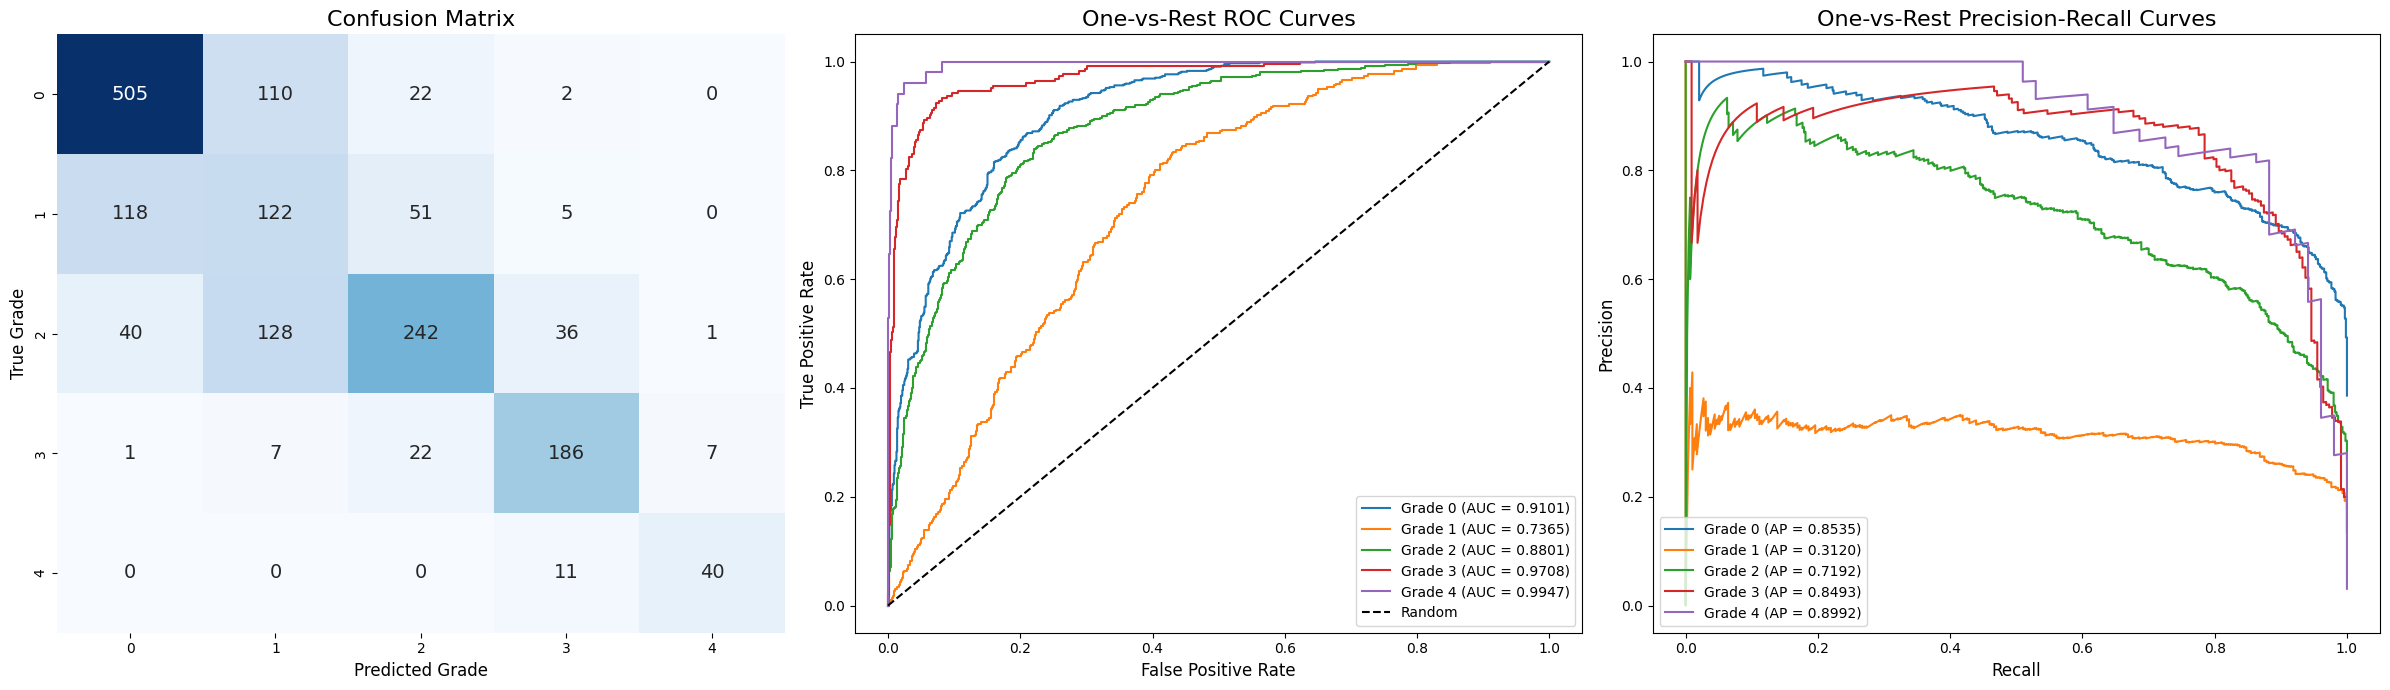

In [15]:
# 3. Plotting Diagrams
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    has_sns = True
except ImportError:
    has_sns = False

plt.figure(figsize=(24, 7))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_true, y_pred)
if has_sns:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(5)], yticklabels=[str(i) for i in range(5)], cbar=False, annot_kws={"size": 14})
else:
    plt.imshow(cm, cmap='Blues')
    for i in range(5):
        for j in range(5):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Grade", fontsize=12)
plt.ylabel("True Grade", fontsize=12)

# Plot 2: ROC Curves (OVR)
plt.subplot(1, 3, 2)
for i in range(5):
    fpr, tpr, _ = roc_curve(y_one_hot[:, i], y_probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Grade {i} (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.title("One-vs-Rest ROC Curves", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")

# Plot 3: Precision-Recall Curves (OVR)
plt.subplot(1, 3, 3)
for i in range(5):
    precision, recall, _ = precision_recall_curve(y_one_hot[:, i], y_probas[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Grade {i} (AP = {pr_auc:.4f})")
plt.title("One-vs-Rest Precision-Recall Curves", fontsize=16)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 13. Grad-CAM Visualizer
Gradient-weighted Class Activation Mapping (Grad-CAM) helps visualize which parts of the knee X-ray image the model is paying attention to when making a prediction.


In [19]:
# Helper to dynamically find the correct target layer in the model
def get_target_layer(model):
    # To get highly localized heatmaps for DenseNet, target the very last conv layer (conv2) of the final dense block.
    # For densenet201 (which is used as the backbone in both notebooks), this is denseblock4.denselayer32.conv2.
    if hasattr(model, 'backbone'):
        features = getattr(model.backbone, 'features', model.backbone)
        if hasattr(features, 'denseblock4'):
            denseblock = features.denseblock4
            if hasattr(denseblock, 'denselayer32'):
                layer = denseblock.denselayer32
                if hasattr(layer, 'conv2'):
                    return layer.conv2
            # Fallback for other densenet versions (like densenet121 which has 16 layers in denseblock4)
            for name, module in reversed(list(denseblock.named_modules())):
                if 'conv2' in name:
                    return module
                    
    if hasattr(model, 'model') and hasattr(model.model, 'features'):
        features = model.model.features
        if hasattr(features, 'denseblock4'):
            denseblock = features.denseblock4
            for name, module in reversed(list(denseblock.named_modules())):
                if 'conv2' in name:
                    return module
        target = getattr(features, 'norm5', None)
        if target is not None:
            return target
            
    # Fallback to the last Conv2d of the entire model
    for module in reversed(list(model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    return None


In [21]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.features = None
        
        # Register hooks
        self.hook_forward = self.target_layer.register_forward_hook(self.save_features)
        if hasattr(self.target_layer, "register_full_backward_hook"):
            self.hook_backward = self.target_layer.register_full_backward_hook(self.save_gradients)
        else:
            self.hook_backward = self.target_layer.register_backward_hook(self.save_gradients)
        
    def save_features(self, module, input, output):
        self.features = output.clone()
        
    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].clone()
        
    def __call__(self, x, class_idx=None):
        self.model.eval()
        
        # Ensure gradients are enabled for the backward pass
        with torch.enable_grad():
            output = self.model(x)
            
            loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else (TrainingConfig.loss_stage2 if TrainingConfig.training_pipeline == "2-stage" else TrainingConfig.loss_standard)
            predict_fn = get_prediction_helper(loss_type)
            
            if class_idx is None:
                class_idx = predict_fn(output).item()
                
            self.model.zero_grad()
            
            if loss_type == "ce":
                loss = output[0, class_idx]
            else:
                logits = output[0]  # Shape: (4,)
                probs = torch.sigmoid(logits)
                
                # SOTA Ordinal Log-Probability Backpropagation
                if loss_type in ["corn", "focal_corn"]:
                    if class_idx == 0:
                        loss = torch.log(1.0 - probs[0] + 1e-10)
                    elif class_idx == 4:
                        loss = torch.sum(torch.log(probs + 1e-10))
                    else:
                        log_probs = torch.log(probs + 1e-10)
                        loss = torch.sum(log_probs[:class_idx]) + torch.log(1.0 - probs[class_idx] + 1e-10)
                elif loss_type in ["threshold", "coral"]:
                    if class_idx == 0:
                        loss = torch.log(1.0 - probs[0] + 1e-10)
                    elif class_idx == 4:
                        loss = torch.log(probs[3] + 1e-10)
                    else:
                        loss = torch.log(probs[class_idx - 1] - probs[class_idx] + 1e-10)
                else:
                    loss = output[0, class_idx]
                
            loss.backward()
            
        # Pool gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        # Apply weights to features
        cam = torch.sum(weights * self.features, dim=1).squeeze(0)
        
        # Apply ReLU to retain positive influence features
        cam = F.relu(cam)
        cam = cam.cpu().detach().numpy()
        
        if cam.max() > 0:
            cam = cam / cam.max()
            
        # Resize to input tensor width and height (correctly shape-swapped for OpenCV)
        cam = cv2.resize(cam, (x.shape[3], x.shape[2]))
        return cam, class_idx
        
    def remove_hooks(self):
        self.hook_forward.remove()
        self.hook_backward.remove()

def show_gradcam(image_path, model, target_layer, transform):
    if not os.path.exists(image_path):
        print(f"Error: Image not found at {image_path}")
        return
        
    # Read and preprocess image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Process original image dimensions for display
    pad = SquarePadOpenCV()
    clahe = OpenCVCLAHE()
    img_processed = clahe(pad(img_rgb))
    img_resized = cv2.resize(img_processed, (IMG_SIZE, IMG_SIZE))
    
    # Tensor transform
    tensor = transform(img_rgb).unsqueeze(0).to(device)
    
    # Run Grad-CAM
    gradcam = GradCAM(model, target_layer)
    cam, class_idx = gradcam(tensor)
    gradcam.remove_hooks()
    
    # Create colormap overlay
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    alpha = 0.4
    overlay = cv2.addWeighted(img_resized, 1 - alpha, heatmap, alpha, 0)
    
    # Plot side-by-side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original Knee X-ray (Processed)")
    plt.imshow(img_resized)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM Heatmap (Predicted Grade: {class_idx})")
    plt.imshow(overlay)
    plt.axis('off')
    
    plt.show()


Loading best model weights from: /content/drive/MyDrive/Models/densenet121_checkpoints/best_model.pth

--- Visualizing Grade 0 ---


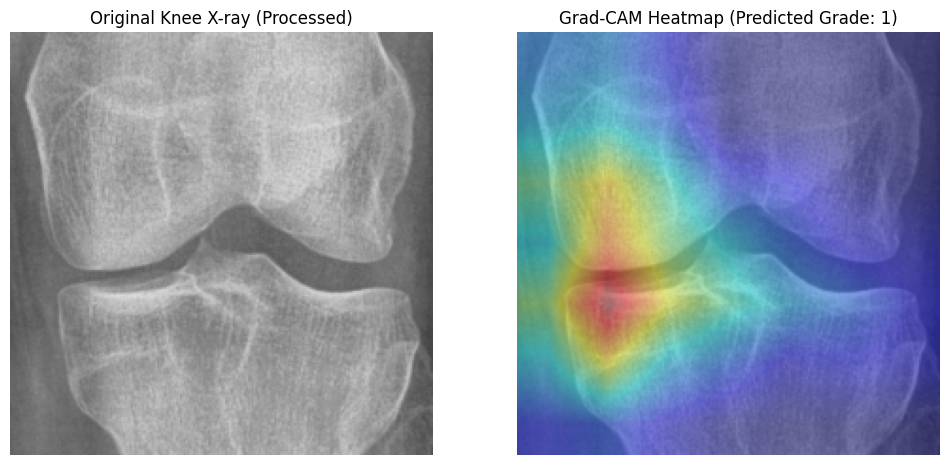


--- Visualizing Grade 1 ---


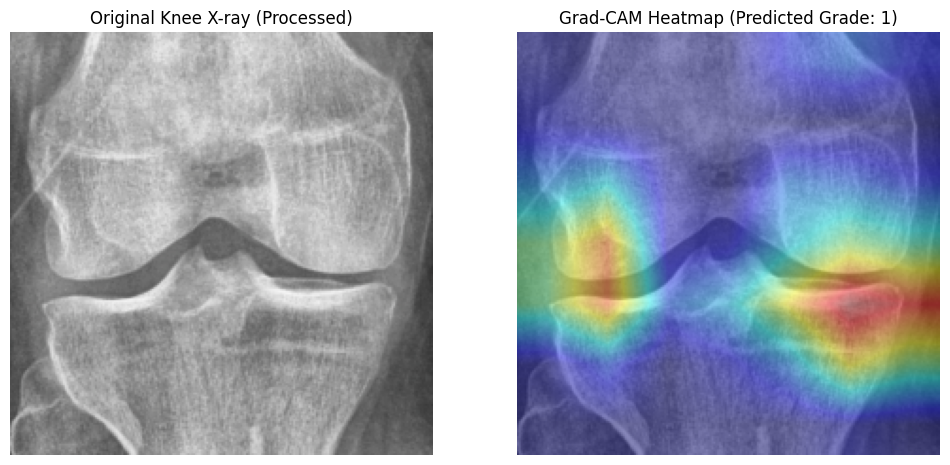


--- Visualizing Grade 2 ---


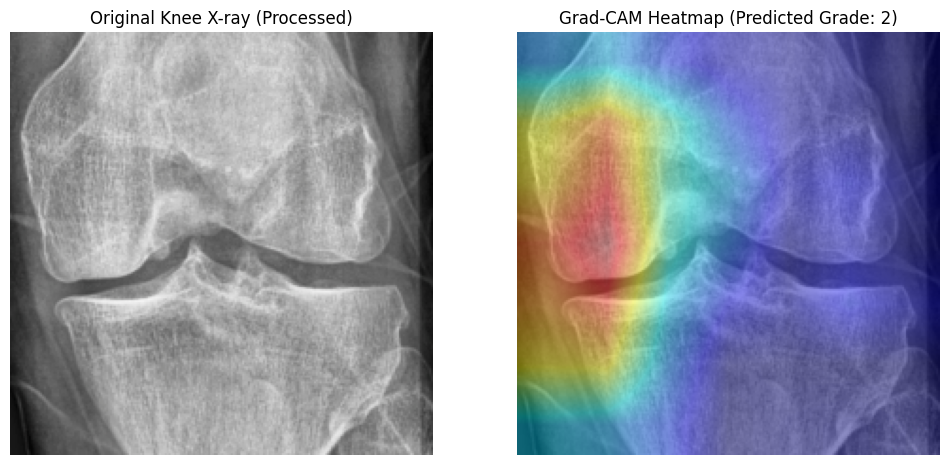


--- Visualizing Grade 3 ---


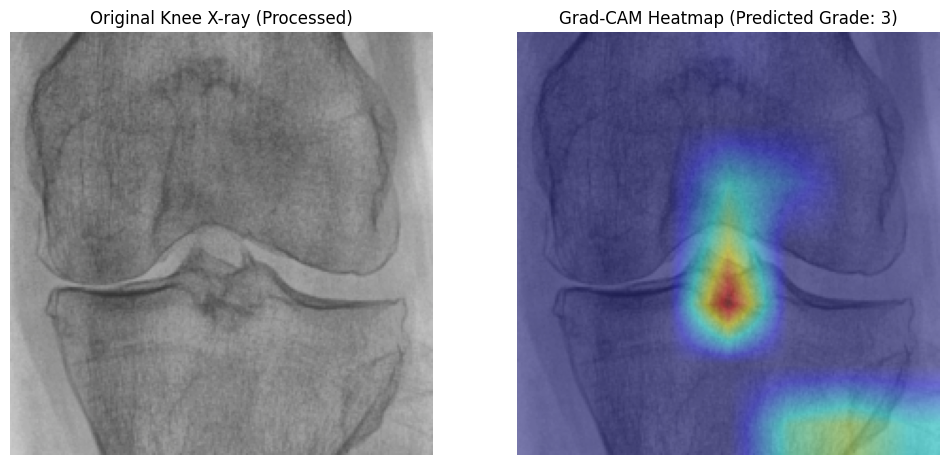


--- Visualizing Grade 4 ---


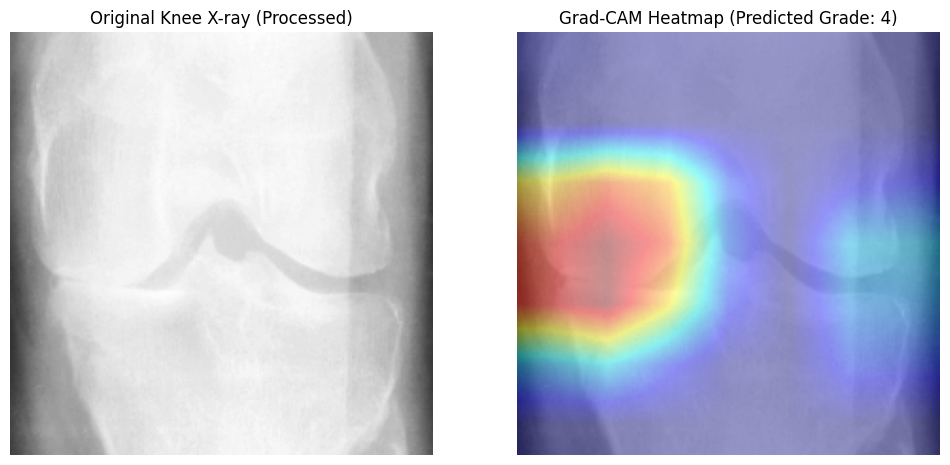

In [22]:
# Instantiate model instance and load best checkpoint weights
loss_type_current = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else (TrainingConfig.loss_stage2 if TrainingConfig.training_pipeline == "2-stage" else TrainingConfig.loss_standard)
best_model = DenseNet201Model(num_classes=5, pretrained=False, loss_type=loss_type_current)

best_weight_path = os.path.join(TrainingConfig.checkpoint_dir, "best_model_stage2.pth")
if not os.path.exists(best_weight_path):
    best_weight_path = os.path.join(TrainingConfig.checkpoint_dir, "best_model.pth")

print(f"Loading best model weights from: {best_weight_path}")
try:
    checkpoint = torch.load(best_weight_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_weight_path, map_location=device)

if 'model_state_dict' in checkpoint:
    best_model.load_state_dict(checkpoint['model_state_dict'])
elif 'model' in checkpoint:
    best_model.load_state_dict(checkpoint['model'])
else:
    best_model.load_state_dict(checkpoint)

best_model = best_model.to(device)
target_layer = get_target_layer(best_model)

# Select dynamically from test/val dataset to visualize
dataset_to_use = val_dataset if 'val_dataset' in globals() else (test_dataset if 'test_dataset' in globals() else None)
if dataset_to_use is not None:
    # Get one example image per class grade (0-4)
    class_indices = {i: None for i in range(5)}
    for idx, label in enumerate(dataset_to_use.labels):
        if class_indices[label] is None:
            class_indices[label] = dataset_to_use.image_paths[idx]
    for grade, path in sorted(class_indices.items()):
        if path is not None and os.path.exists(path):
            print(f"\n--- Visualizing Grade {grade} ---")
            show_gradcam(path, best_model, target_layer, val_transform)
else:
    print("Dataset loader not active in environment. Run previous cells to load datasets.")


In [17]:
# =========================================================================
# 14. DIAGNOSTIC ERROR ANALYSIS & CRITICAL MISS DETECTOR
# =========================================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_error_analysis(model, val_loader, dataset_root, output_dir="error_analysis_diagnostics"):
    """
    Diagnoses misclassifications on the validation set, copying critical failure
    cases (e.g. underpredicted severe OA) to categorized diagnostic folders for inspection.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Create subfolders for specific failure categories
    categories = [
        "critical_miss_underpredict",  # True Grade 3/4 predicted as 0/1
        "critical_miss_overpredict",   # True Grade 0/1 predicted as 3/4
        "boundary_confusion",          # Confusions off by exactly 1 grade
        "other_errors"                 # The rest of the mismatches
    ]
    
    shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)
    for cat in categories:
        os.makedirs(os.path.join(output_dir, cat), exist_ok=True)
        
    error_log = []
    dataset = val_loader.dataset
    
    # Get correct prediction function depending on loss type
    loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else TrainingConfig.loss_standard
    predict_fn = get_prediction_helper(loss_type)
    
    print("\n[Diagnostic Engine] Running batch inference on validation set...")
    with torch.no_grad():
        for idx, (images, targets) in enumerate(tqdm(val_loader)):
            images = images.to(device)
            outputs = model(images)
            preds = predict_fn(outputs).cpu().numpy()
            targets = targets.cpu().numpy()
            
            # Extract probabilities
            if loss_type in ["corn", "focal_corn", "threshold", "coral"]:
                # Sigmoid activation for ordinal models
                probs = torch.sigmoid(outputs).cpu().numpy()
            else:
                # Softmax activation for standard CrossEntropy
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                
            for i in range(len(preds)):
                pred = int(preds[i])
                target = int(targets[i])
                
                if pred != target:
                    # Map back to the absolute original image path
                    global_idx = idx * val_loader.batch_size + i
                    if global_idx < len(dataset):
                        img_path = dataset.image_paths[global_idx]
                        
                        # Categorize the severity of the failure
                        if target in [3, 4] and pred in [0, 1]:
                            cat = "critical_miss_underpredict"
                        elif target in [0, 1] and pred in [3, 4]:
                            cat = "critical_miss_overpredict"
                        elif abs(target - pred) == 1:
                            cat = "boundary_confusion"
                        else:
                            cat = "other_errors"
                            
                        # Generate formatted diagnostic file name
                        img_name = os.path.basename(img_path)
                        prob_val = probs[i][pred] if pred < len(probs[i]) else 0.0
                        new_name = f"true_G{target}_pred_G{pred}_conf_{prob_val:.2f}_{img_name}"
                        dest_path = os.path.join(output_dir, cat, new_name)
                        
                        # Copy original image to the correct category subfolder
                        shutil.copy(img_path, dest_path)
                        
                        error_log.append({
                            "filename": img_name,
                            "original_path": img_path,
                            "true_grade": target,
                            "predicted_grade": pred,
                            "confidence": prob_val,
                            "error_category": cat
                        })
                        
    df_errors = pd.DataFrame(error_log)
    csv_path = os.path.join(output_dir, "error_analysis_log.csv")
    df_errors.to_csv(csv_path, index=False)
    
    # Output Summary Diagnostics to Console
    print("\n" + "="*60)
    print("          DIAGNOSTIC ERROR ANALYSIS RESULTS")
    print("="*60)
    print(f"Total Validation Failures: {len(df_errors)} / {len(dataset)} ({len(df_errors)/len(dataset)*100:.2f}% error)")
    
    if not df_errors.empty:
        print("\nDistribution by Severity Category:")
        print(df_errors["error_category"].value_counts().to_string())
        
        print("\nTop 5 Most Common Confusions (True vs Pred):")
        confusion_matrix_summary = df_errors.groupby(["true_grade", "predicted_grade"]).size().reset_index(name="count")
        print(confusion_matrix_summary.sort_values(by="count", ascending=False).head(5).to_string(index=False))
        
        print(f"\nSaved diagnostic images and CSV index to: {os.path.abspath(output_dir)}/")
    print("="*60)


In [18]:
# Load best stage 3 model and analyze errors
best_model_path = stage3_best_path
if os.path.exists(best_model_path):
    print(f"Loading best model parameters from: {best_model_path}")
    try:
        checkpoint_s3 = torch.load(best_model_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint_s3 = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint_s3['model_state_dict'])
    
    # Run the error analysis
    run_error_analysis(model, val_loader, DATASET_ROOT_PATH)
else:
    print(f"Error: SOTA Stage 3 weights not found at {best_model_path}. Run training first.")


Loading best model parameters from: /content/drive/MyDrive/Models/densenet121_checkpoints/best_model.pth

[Diagnostic Engine] Running batch inference on validation set...


100%|██████████| 52/52 [00:05<00:00,  9.24it/s]


          DIAGNOSTIC ERROR ANALYSIS RESULTS
Total Validation Failures: 288 / 826 (34.87% error)

Distribution by Severity Category:
error_category
boundary_confusion            243
other_errors                   37
critical_miss_overpredict       4
critical_miss_underpredict      4

Top 5 Most Common Confusions (True vs Pred):
 true_grade  predicted_grade  count
          1                0     63
          2                1     63
          0                1     58
          2                0     20
          1                2     20

Saved diagnostic images and CSV index to: /content/error_analysis_diagnostics/
